In [16]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
## Load S&P 500 Data (using monthly for manageability)
sp500_data = pd.read_csv('../../data/yfinance/sp500_yfinance_monthly.csv')
# sp500_data = pd.read_csv('../../data/merged_sec_yfin/sp500_sec_yfin_quarterly.csv')
print(f"S&P 500 Data Shape: {sp500_data.shape}")
print(f"\nDate Range: {sp500_data['Date'].min()} to {sp500_data['Date'].max()}")
sp500_data = sp500_data.dropna(subset=['Close'])
print(f"\nNumber of Companies: {sp500_data['Ticker'].nunique()}")
print(f"\nMissing Values:\n{sp500_data.isnull().sum()}")
sp500_data

S&P 500 Data Shape: (114880, 10)

Date Range: 2005-01-31 to 2025-12-31

Number of Companies: 501

Missing Values:
Date             0
Month            0
Quarter          0
Year             0
Company          0
Ticker           0
industryKey    252
sectorKey      252
Close            0
Volume           0
dtype: int64


,Date,Month,Quarter,Year,Company,Ticker,industryKey,sectorKey,Close,Volume
0,2005-01-31,1,1,2005,3M,MMM,conglomerates,industrials,38.180622,3349637.0
1,2005-02-28,2,1,2005,3M,MMM,conglomerates,industrials,38.181286,2587307.0
2,2005-03-31,3,1,2005,3M,MMM,conglomerates,industrials,38.977291,3120842.0
3,2005-04-30,4,2,2005,3M,MMM,conglomerates,industrials,34.783459,3535137.0
4,2005-05-31,5,2,2005,3M,MMM,conglomerates,industrials,35.056538,3991052.0
...,...,...,...,...,...,...,...,...,...,...
114875,2025-08-31,8,3,2025,Zoetis,ZTS,drug-manufacturers-specialty-generic,healthcare,155.194626,1534600.0
114876,2025-09-30,9,3,2025,Zoetis,ZTS,drug-manufacturers-specialty-generic,healthcare,145.192322,3736800.0
114877,2025-10-31,10,4,2025,Zoetis,ZTS,drug-manufacturers-specialty-generic,healthcare,143.477341,3338200.0
114878,2025-11-30,11,4,2025,Zoetis,ZTS,drug-manufacturers-specialty-generic,healthcare,127.634987,2143000.0


In [19]:
## Load Gig Economy Data
gig_data = pd.read_csv('../../data/yfinance/gig_yfinance_monthly.csv')
print(f"Gig Data Shape: {gig_data.shape}")
print(f"\nColumns: {gig_data.columns.tolist()}")
print(f"\nDate Range: {gig_data['Date'].min()} to {gig_data['Date'].max()}")
# print(f"\nCompanies: {gig_data['Company'].unique().tolist()}")
gig_data = gig_data.dropna(subset=['Close'])
print(f"\nMissing Values:\n{gig_data.isnull().sum()}")
gig_data

Gig Data Shape: (1670, 10)

Columns: ['Date', 'Month', 'Quarter', 'Year', 'Company', 'Ticker', 'industryKey', 'sectorKey', 'Close', 'Volume']

Date Range: 2005-01-31 to 2025-12-31

Missing Values:
Date           0
Month          0
Quarter        0
Year           0
Company        0
Ticker         0
industryKey    0
sectorKey      0
Close          0
Volume         0
dtype: int64


,Date,Month,Quarter,Year,Company,Ticker,industryKey,sectorKey,Close,Volume
0,2018-10-31,10,4,2018,Upwork,UPWK,internet-content-information,communication-services,19.200001,337600.0
1,2018-11-30,11,4,2018,Upwork,UPWK,internet-content-information,communication-services,18.629999,352700.0
2,2018-12-31,12,4,2018,Upwork,UPWK,internet-content-information,communication-services,18.110001,337200.0
3,2019-01-31,1,1,2019,Upwork,UPWK,internet-content-information,communication-services,19.309999,368200.0
4,2019-02-28,2,1,2019,Upwork,UPWK,internet-content-information,communication-services,23.690001,447200.0
...,...,...,...,...,...,...,...,...,...,...
1665,2025-08-31,8,3,2025,USANA,USNA,packaged-foods,consumer-defensive,31.910000,77300.0
1666,2025-09-30,9,3,2025,USANA,USNA,packaged-foods,consumer-defensive,27.549999,141200.0
1667,2025-10-31,10,4,2025,USANA,USNA,packaged-foods,consumer-defensive,21.150000,520700.0
1668,2025-11-30,11,4,2025,USANA,USNA,packaged-foods,consumer-defensive,19.850000,85200.0


In [20]:
# datafram of all rolws isnull
null_rows = sp500_data[sp500_data.isnull().any(axis=1)]
null_rows

,Date,Month,Quarter,Year,Company,Ticker,industryKey,sectorKey,Close,Volume
45878,2005-01-31,1,1,2005,Fiserv,FISV,NaN,NaN,9.562500,10780400.0
45879,2005-02-28,2,1,2005,Fiserv,FISV,NaN,NaN,9.485000,5691200.0
45880,2005-03-31,3,1,2005,Fiserv,FISV,NaN,NaN,9.950000,9264800.0
45881,2005-04-30,4,2,2005,Fiserv,FISV,NaN,NaN,10.575000,8893600.0
45882,2005-05-31,5,2,2005,Fiserv,FISV,NaN,NaN,10.747500,11300400.0
...,...,...,...,...,...,...,...,...,...,...
46125,2025-08-31,8,3,2025,Fiserv,FISV,NaN,NaN,138.179993,3769800.0
46126,2025-09-30,9,3,2025,Fiserv,FISV,NaN,NaN,128.929993,4764300.0
46127,2025-10-31,10,4,2025,Fiserv,FISV,NaN,NaN,66.690002,30157000.0
46128,2025-11-30,11,4,2025,Fiserv,FISV,NaN,NaN,61.470001,6770500.0


In [80]:
# combine gig and sp500 data with an indicator column
sp500_data['Category'] = sp500_data['industryKey']  # Keep original sector for S&P 500
gig_data['Category'] = 'gig-work'  # Label for gig economy companies
combined_data = pd.concat([sp500_data, gig_data], ignore_index=True)
# combined_data.columns = [col.capitalize() for col in combined_data.columns]
print(f"Combined Data Shape: {combined_data.shape}")
print(f"\nCombined Data Columns: {combined_data.columns.tolist()}")
print(f"\nCombined Data Sample:\n{combined_data.head()}")

combined_data = combined_data.drop(columns=['industryKey', 'sectorKey'], errors='ignore')
input_data = combined_data.dropna().copy()
input_data

Combined Data Shape: (116550, 11)

Combined Data Columns: ['Date', 'Month', 'Quarter', 'Year', 'Company', 'Ticker', 'industryKey', 'sectorKey', 'Close', 'Volume', 'Category']

Combined Data Sample:
         Date  Month  Quarter  Year Company Ticker    industryKey  \
0  2005-01-31      1        1  2005      3M    MMM  conglomerates   
1  2005-02-28      2        1  2005      3M    MMM  conglomerates   
2  2005-03-31      3        1  2005      3M    MMM  conglomerates   
3  2005-04-30      4        2  2005      3M    MMM  conglomerates   
4  2005-05-31      5        2  2005      3M    MMM  conglomerates   

     sectorKey      Close     Volume       Category  
0  industrials  38.180622  3349637.0  conglomerates  
1  industrials  38.181286  2587307.0  conglomerates  
2  industrials  38.977291  3120842.0  conglomerates  
3  industrials  34.783459  3535137.0  conglomerates  
4  industrials  35.056538  3991052.0  conglomerates  


,Date,Month,Quarter,Year,Company,Ticker,Close,Volume,Category
0,2005-01-31,1,1,2005,3M,MMM,38.180622,3349637.0,conglomerates
1,2005-02-28,2,1,2005,3M,MMM,38.181286,2587307.0,conglomerates
2,2005-03-31,3,1,2005,3M,MMM,38.977291,3120842.0,conglomerates
3,2005-04-30,4,2,2005,3M,MMM,34.783459,3535137.0,conglomerates
4,2005-05-31,5,2,2005,3M,MMM,35.056538,3991052.0,conglomerates
...,...,...,...,...,...,...,...,...,...
116545,2025-08-31,8,3,2025,USANA,USNA,31.910000,77300.0,gig-work
116546,2025-09-30,9,3,2025,USANA,USNA,27.549999,141200.0,gig-work
116547,2025-10-31,10,4,2025,USANA,USNA,21.150000,520700.0,gig-work
116548,2025-11-30,11,4,2025,USANA,USNA,19.850000,85200.0,gig-work


In [81]:
# group by Ticker and determine earliest start date(i.e. first date) for each company
earliest_start_dates = input_data.groupby('Ticker')['Date'].min().reset_index()
earliest_start_dates.columns = ['Ticker', 'EarliestStartDate']
# sort by earliest start date
earliest_start_dates = earliest_start_dates.sort_values(by='EarliestStartDate', ascending=True)
print(f"Earliest Start Dates:\n{earliest_start_dates.head()}")

# determine which company has the latest start date(500th company)
latest_start_date = earliest_start_dates['EarliestStartDate'].iloc[450]
print(f"\nLatest Start Date: {latest_start_date}")

# use this date to filter the combined dataset to only include companies that have data starting from this date or earlier
input_data_clean = input_data[input_data['Date'] >= latest_start_date].copy()
print(f"\nCleaned Data Shape: {input_data_clean.shape}")
print(f"\nDate Range after cleaning: {input_data_clean['Date'].min()} to {input_data_clean['Date'].max()}")
print(f"\nNumber of Companies after cleaning: {input_data_clean['Ticker'].nunique()}")
print(f"\nMissing Values after cleaning:\n{input_data_clean.isnull().sum()}")
input_data_clean.reset_index(drop=True, inplace=True)
input_data_clean.head()

Earliest Start Dates:
  Ticker EarliestStartDate
0      A        2005-01-31
1   AAPL        2005-01-31
4    ABT        2005-01-31
5   ACGL        2005-01-31
6    ACN        2005-01-31

Latest Start Date: 2013-01-31

Cleaned Data Shape: (76071, 9)

Date Range after cleaning: 2013-01-31 to 2025-12-31

Number of Companies after cleaning: 511

Missing Values after cleaning:
Date        0
Month       0
Quarter     0
Year        0
Company     0
Ticker      0
Close       0
Volume      0
Category    0
dtype: int64


,Date,Month,Quarter,Year,Company,Ticker,Close,Volume,Category
0,2013-01-31,1,1,2013,3M,MMM,55.991947,4500668.0,conglomerates
1,2013-02-28,2,1,2013,3M,MMM,58.270748,3432640.0,conglomerates
2,2013-03-31,3,1,2013,3M,MMM,59.565060,2722933.0,conglomerates
3,2013-04-30,4,2,2013,3M,MMM,58.668568,4507485.0,conglomerates
4,2013-05-31,5,2,2013,3M,MMM,62.136059,3836409.0,conglomerates


In [82]:
## Feature Engineering for Gig Economy Companies

# Convert Date to datetime
input_data_clean['Date'] = pd.to_datetime(input_data_clean['Date'])

# Calculate returns
input_data_clean = input_data_clean.sort_values(['Ticker', 'Date'])
input_data_clean['Return'] = input_data_clean.groupby('Ticker')['Close'].pct_change()
input_data_clean['Log_Return'] = input_data_clean.groupby('Ticker')['Close'].transform(lambda x: np.log(x / x.shift(1)))

# Volume changes
input_data_clean['Volume_Change'] = input_data_clean.groupby('Ticker')['Volume'].pct_change()

# Rolling statistics (3-month window)
for ticker in input_data_clean['Ticker'].unique():
    mask = input_data_clean['Ticker'] == ticker
    input_data_clean.loc[mask, 'Volatility_3M'] = input_data_clean.loc[mask, 'Return'].rolling(window=3).std()
    input_data_clean.loc[mask, 'Avg_Return_3M'] = input_data_clean.loc[mask, 'Return'].rolling(window=3).mean()
    input_data_clean.loc[mask, 'Avg_Volume_3M'] = input_data_clean.loc[mask, 'Volume'].rolling(window=3).mean()

# Remove NaN values created by calculations
input_df = input_data_clean.dropna()

print(f"Data shape after feature engineering: {input_df.shape}")
input_df.head(10)

Data shape after feature engineering: (74445, 15)


,Date,Month,Quarter,Year,Company,Ticker,Close,Volume,Category,Return,Log_Return,Volume_Change,Volatility_3M,Avg_Return_3M,Avg_Volume_3M
1407,2013-04-30,4,2,2013,Agilent Technologies,A,26.627642,4825057.0,diagnostics-research,-0.012628,-0.012709,0.606797,0.045260,-0.023872,4.221308e+06
1408,2013-05-31,5,2,2013,Agilent Technologies,A,29.204302,6442543.0,diagnostics-research,0.096766,0.092366,0.335226,0.056933,0.032948,4.756835e+06
1409,2013-06-30,6,2,2013,Agilent Technologies,A,27.552555,7767707.0,diagnostics-research,-0.056558,-0.058221,0.205690,0.078957,0.009193,6.345102e+06
1410,2013-07-31,7,3,2013,Agilent Technologies,A,28.821941,3924745.0,diagnostics-research,0.046071,0.045042,-0.494736,0.078115,0.028760,6.044998e+06
1411,2013-08-31,8,3,2013,Agilent Technologies,A,30.052658,1899323.0,diagnostics-research,0.042701,0.041814,-0.516065,0.058305,0.010738,4.530592e+06
1412,2013-09-30,9,3,2013,Agilent Technologies,A,33.099373,3704700.0,diagnostics-research,0.101379,0.096563,0.950537,0.032948,0.063384,3.176256e+06
1413,2013-10-31,10,4,2013,Agilent Technologies,A,32.782917,2649909.0,diagnostics-research,-0.009561,-0.009607,-0.284717,0.055501,0.044840,2.751311e+06
1414,2013-11-30,11,4,2013,Agilent Technologies,A,34.597733,1216819.0,diagnostics-research,0.055359,0.053881,-0.540807,0.055738,0.049059,2.523809e+06
1415,2013-12-31,12,4,2013,Agilent Technologies,A,37.020714,1316077.0,diagnostics-research,0.070033,0.067689,0.081572,0.042358,0.038610,1.727602e+06
1416,2014-01-31,1,1,2014,Agilent Technologies,A,37.642166,4804227.0,diagnostics-research,0.016787,0.016647,2.650415,0.027502,0.047393,2.445708e+06


In [83]:
## Create Category-Level Aggregated Features

# Aggregate metrics by category for clustering
category_features = input_data_clean.groupby('Category').agg({
    'Close': ['mean', 'std', 'min', 'max'],
    'Volume': ['mean', 'std'],
    'Return': ['mean', 'std', 'skew'],
    'Volatility_3M': ['mean', 'max'],
    'Avg_Return_3M': 'mean',
    'Avg_Volume_3M': 'mean'
}).reset_index()

# Flatten column names
category_features.columns = ['_'.join(col).strip('_') for col in category_features.columns.values]
category_features.rename(columns={'Category_': 'Category'}, inplace=True)

category_non_numeric = ['Category']


# Add category names back
category_mapping = input_data_clean[category_non_numeric].drop_duplicates()
category_features = category_features.merge(category_mapping, on='Category', how='left')

print(f"\nCategory-level features shape: {category_features.shape}")
print(f"\nFeatures:\n{category_features.columns.tolist()}")
category_features = category_features.dropna()
category_features.head()


Category-level features shape: (110, 14)

Features:
['Category', 'Close_mean', 'Close_std', 'Close_min', 'Close_max', 'Volume_mean', 'Volume_std', 'Return_mean', 'Return_std', 'Return_skew', 'Volatility_3M_mean', 'Volatility_3M_max', 'Avg_Return_3M_mean', 'Avg_Volume_3M_mean']


,Category,Close_mean,Close_std,Close_min,Close_max,Volume_mean,Volume_std,Return_mean,Return_std,Return_skew,Volatility_3M_mean,Volatility_3M_max,Avg_Return_3M_mean,Avg_Volume_3M_mean
0,advertising-agencies,71.920303,88.067576,2.518000,718.539978,4.822335e+06,6.200256e+06,0.029962,0.161888,1.533177,0.121519,0.548127,0.029788,4.840054e+06
1,aerospace-defense,180.195865,183.621731,7.470000,1504.976196,3.277677e+06,5.080102e+06,0.018118,0.086492,0.300768,0.070749,0.334188,0.017983,3.290048e+06
2,agricultural-inputs,40.748344,19.328229,9.576127,100.360931,4.399964e+06,2.914979e+06,0.008099,0.100081,-0.030146,0.088095,0.257457,0.008465,4.412840e+06
3,airlines,45.015625,17.560452,9.699602,111.519997,8.424627e+06,7.123541e+06,0.016175,0.108478,-0.050860,0.093775,0.248598,0.014973,8.466273e+06
4,apparel-manufacturing,122.266779,58.351681,57.041954,366.402313,1.030721e+06,6.745634e+05,0.011340,0.098223,0.025026,0.089023,0.248138,0.011120,1.033534e+06


In [84]:
## Prepare features for clustering

# Select numeric features for clustering
feature_cols = [col for col in category_features.columns if col not in category_non_numeric]
X = category_features[feature_cols].values
ticker_labels = category_features['Category'].values
company_labels = category_features['Category'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features used for clustering:\n{feature_cols}")

# Standardize the features using RobustScaler (handles outliers better)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled data - Mean: {X_scaled.mean(axis=0)[:5]}")
print(f"Scaled data - Std: {X_scaled.std(axis=0)[:5]}")

Feature matrix shape: (110, 13)
Features used for clustering:
['Close_mean', 'Close_std', 'Close_min', 'Close_max', 'Volume_mean', 'Volume_std', 'Return_mean', 'Return_std', 'Return_skew', 'Volatility_3M_mean', 'Volatility_3M_max', 'Avg_Return_3M_mean', 'Avg_Volume_3M_mean']

Scaled data - Mean: [0.22342786 0.55700554 0.3455144  0.6874991  0.71860124]
Scaled data - Std: [1.5698665  2.71600687 1.18021801 2.60124857 3.10186432]


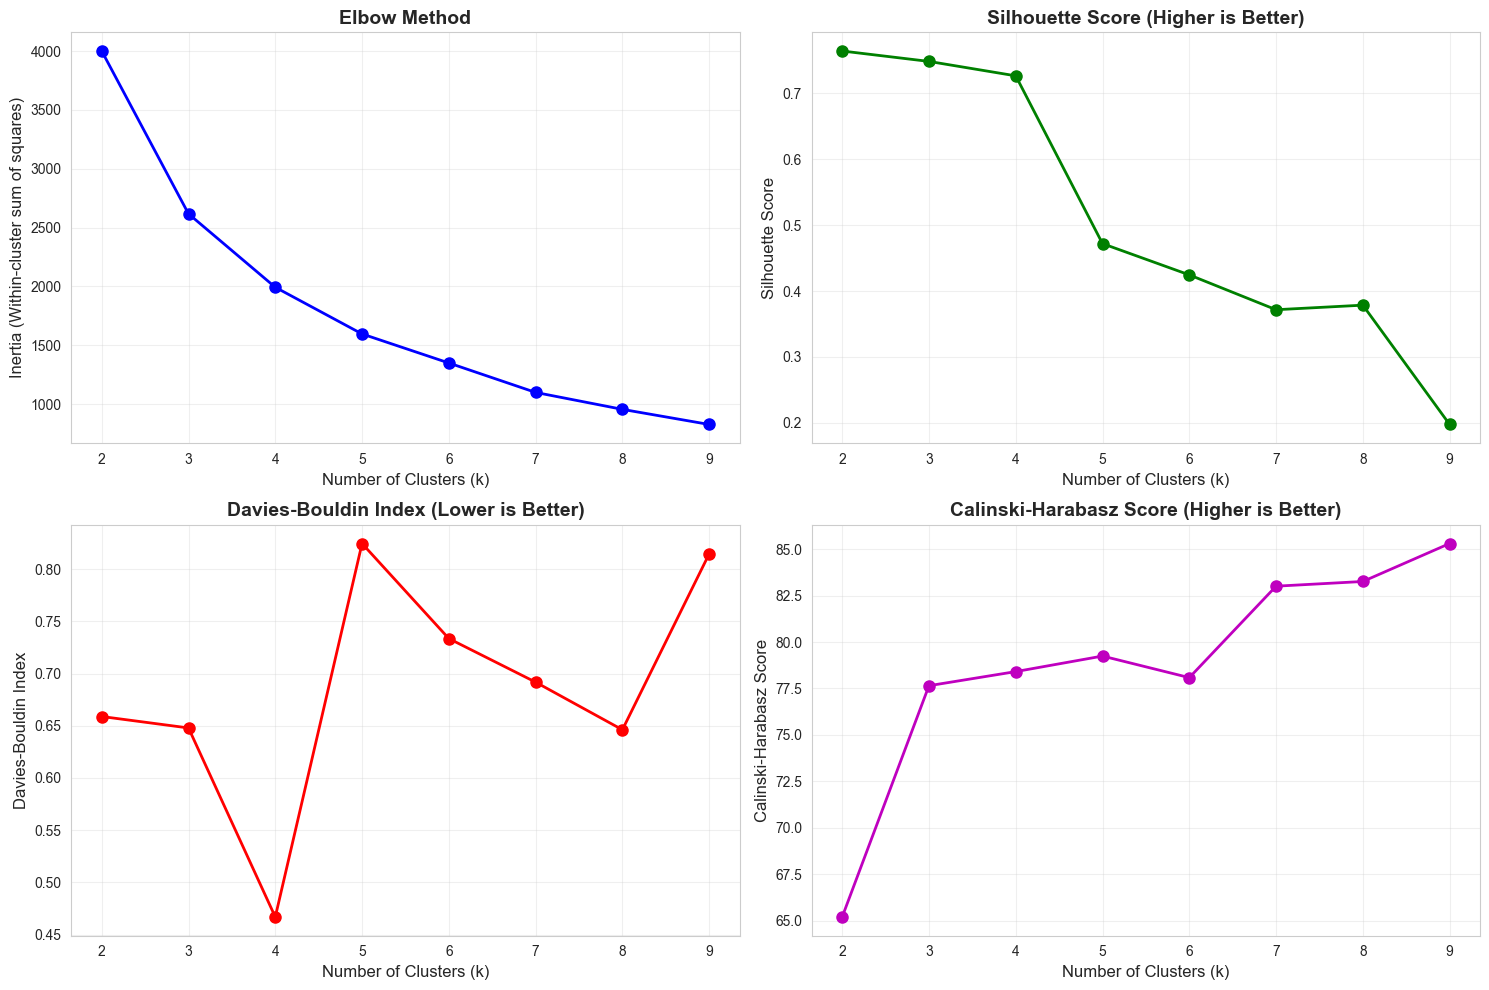

Cluster Evaluation Summary:
   k      Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz  \
0  2  4000.591536    0.763902        0.658884          65.192177   
1  3  2617.042863    0.748119        0.647920          77.651020   
2  4  1992.902292    0.726251        0.466936          78.410361   
3  5  1596.298896    0.471833        0.824523          79.247902   
4  6  1349.461207    0.424433        0.733502          78.085282   
5  7  1099.362501    0.371624        0.691763          83.011662   
6  8   955.499626    0.378538        0.646181          83.264943   
7  9   827.025537    0.197636        0.814597          85.310737   

   Combined_Score  
0        0.365803  
1        0.630309  
2        0.805788  
3        0.485116  
4        0.532823  
5        0.619607  
6        0.669008  
7        0.506940  

Top 3 k by combined normalized metrics: [4, 8, 3]


In [85]:
## Elbow Method and Cluster Evaluation Metrics

k_range = range(2, 10)
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Elbow plot
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Silhouette score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Davies-Bouldin Index
axes[1, 0].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Calinski-Harabasz Index
axes[1, 1].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# normalize the metrics and index of best k given all metrics
# Convert lists to arrays for easier manipulation
inertias_arr = np.array(inertias)
silhouette_arr = np.array(silhouette_scores)
db_arr = np.array(davies_bouldin_scores)
ch_arr = np.array(calinski_harabasz_scores)

# Normalize metrics (min-max scaling)
def minmax(x):
    x = np.array(x)
    return (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x))

norm_inertia = 1 - minmax(inertias_arr)  # lower is better, so invert
norm_silhouette = minmax(silhouette_arr) # higher is better
norm_db = 1 - minmax(db_arr)             # lower is better, so invert
norm_ch = minmax(ch_arr)                 # higher is better

# Combine normalized metrics (average)
combined_score = (norm_inertia + norm_silhouette + norm_db + norm_ch) / 4

# Find the top 3 k (highest combined score)
top_k_idx = np.argsort(combined_score)[-3:][::-1]
top_k = [list(k_range)[i] for i in top_k_idx]

# Show results
metrics_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias_arr,
    'Silhouette': silhouette_arr,
    'Davies-Bouldin': db_arr,
    'Calinski-Harabasz': ch_arr,
    'Combined_Score': combined_score
})

# Print summary
print("Cluster Evaluation Summary:")
print(metrics_df)
print(f"\nTop 3 k by combined normalized metrics: {top_k}")

## 4. K-Means Clustering

Based on the evaluation metrics above, we'll select an optimal k and perform K-Means clustering.

In [86]:
## Apply K-Means with optimal k (you can adjust based on metrics above)
optimal_k = 8  # Adjust based on the metrics above

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to category features
category_features['KMeans_Cluster'] = kmeans_labels

# Calculate metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"K-Means Clustering Results (k={optimal_k}):")
print("=" * 60)
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin Index: {kmeans_db:.3f}")
print(f"Calinski-Harabasz Score: {kmeans_ch:.2f}")
print("\nCluster Distribution:")
print(category_features['KMeans_Cluster'].value_counts().sort_index())
print("\nCategories by Cluster:")
for cluster_id in range(optimal_k):
    categories_in_cluster = category_features[category_features['KMeans_Cluster'] == cluster_id]['Category'].tolist()
    print(f"\nCluster {cluster_id}: {categories_in_cluster}")

K-Means Clustering Results (k=8):
Silhouette Score: 0.379
Davies-Bouldin Index: 0.646
Calinski-Harabasz Score: 83.26

Cluster Distribution:
KMeans_Cluster
0    12
1    85
2     3
3     2
4     1
5     5
6     1
7     1
Name: count, dtype: int64

Categories by Cluster:

Cluster 0: ['advertising-agencies', 'biotechnology', 'building-products-equipment', 'capital-markets', 'computer-hardware', 'financial-data-stock-exchanges', 'gig-work', 'oil-gas-e-p', 'oil-gas-midstream', 'software-infrastructure', 'solar', 'utilities-independent-power-producers']

Cluster 1: ['aerospace-defense', 'agricultural-inputs', 'airlines', 'apparel-manufacturing', 'apparel-retail', 'asset-management', 'banks-regional', 'beverages-brewers', 'beverages-non-alcoholic', 'building-materials', 'chemicals', 'communication-equipment', 'confectioners', 'conglomerates', 'consulting-services', 'credit-services', 'diagnostics-research', 'discount-stores', 'drug-manufacturers-general', 'drug-manufacturers-specialty-generic'

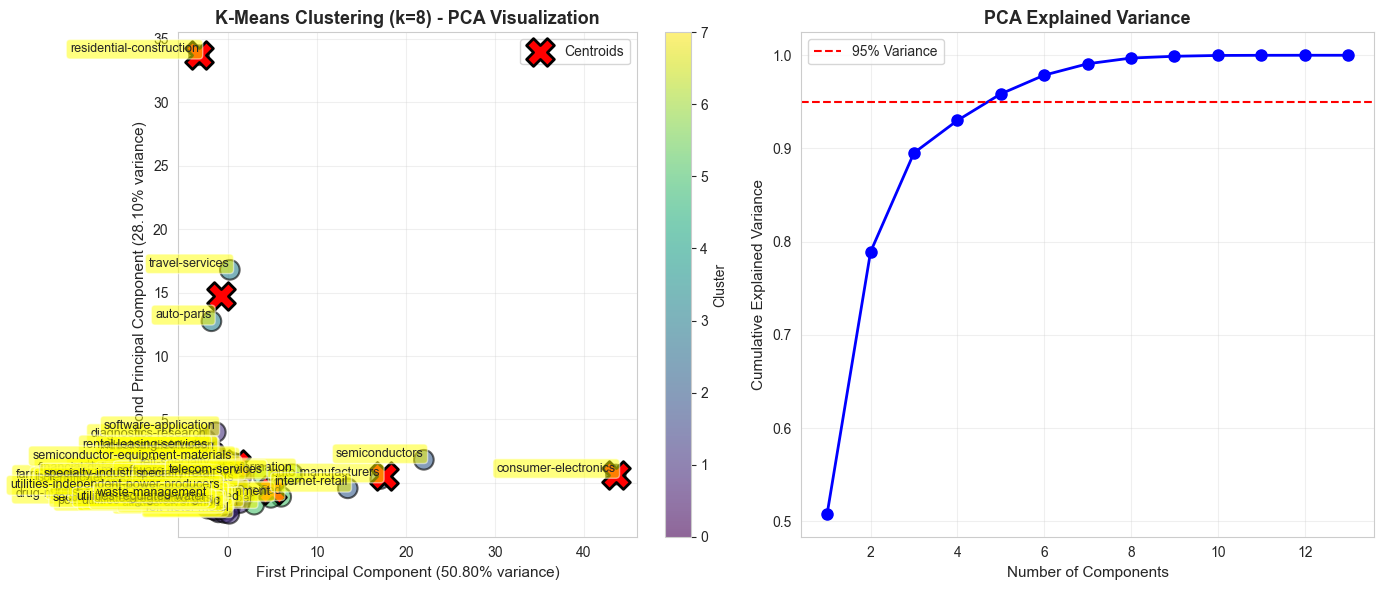


PCA Variance Explained by First 2 Components: 78.90%


In [87]:
## Visualize K-Means Clusters using PCA

# Reduce dimensionality for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create visualization
plt.figure(figsize=(14, 6))

# Plot 1: K-Means clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, 
                     cmap='viridis', s=200, alpha=0.6, edgecolors='black', linewidth=1.5)
plt.scatter(pca.transform(kmeans_final.cluster_centers_)[:, 0], 
           pca.transform(kmeans_final.cluster_centers_)[:, 1], 
           c='red', marker='X', s=400, edgecolors='black', linewidth=2, label='Centroids')

# Annotate points with company names
for i, company in enumerate(company_labels):
    plt.annotate(company, (X_pca[i, 0], X_pca[i, 1]), 
                fontsize=9, ha='right', va='bottom', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=11)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=11)
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA Visualization', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Explained variance
plt.subplot(1, 2, 2)
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.xlabel('Number of Components', fontsize=11)
plt.ylabel('Cumulative Explained Variance', fontsize=11)
plt.title('PCA Explained Variance', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nPCA Variance Explained by First 2 Components: {sum(pca.explained_variance_ratio_):.2%}")